lambda (per hour) = 12
lambda (per min)  = 0.2
میانگین فاصله بین دو چک کردن = 5.00 دقیقه
E[X]        = 5.0000 دقیقه
Var(X)      = 25.0000 دقیقه^2
SD(X)       = 5.0000 دقیقه
P(X > 15)  = 0.0498  (~4.98%)
== بررسی خاصیت بی‌حافظگی ==
P(X > 20 | X > 10) = 0.1353
P(X > 10)            = 0.1353
برابرند؟ True

== LOTUS: E[g(X)] با g(X) = X^2 ==
E[X^2]  از فرمول مستقیم       = 50.0000
E[X^2]  از Var(X) + (E[X])^2  = 50.0000
                             تحلیلی (تئوری)     تجربی (شبیه‌سازی)     خطا (%)
میانگین E[X]                         5.0000                5.0014       0.028
واریانس Var(X)                      25.0000               24.9235       0.306


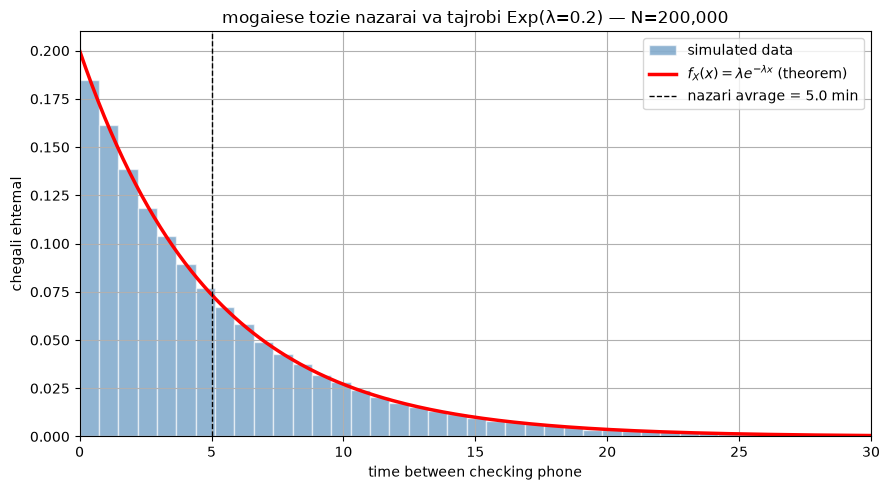

In [6]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True

# نرخ سیستم: به طور میانگین ۱۲ بار چک کردن گوشی در هر ساعت
LAMBDA_PER_HOUR = 12
LAMBDA_PER_MIN  = LAMBDA_PER_HOUR / 60   # = 0.2 بار در دقیقه -> همان توزیع، فقط واحد زمان متفاوت

print(f"lambda (per hour) = {LAMBDA_PER_HOUR}")
print(f"lambda (per min)  = {LAMBDA_PER_MIN}")
print(f"میانگین فاصله بین دو چک کردن = {1/LAMBDA_PER_MIN:.2f} دقیقه")

# محاسبات گام دوم (همه بر حسب دقیقه)
EX  = 1 / LAMBDA_PER_MIN
VarX = 1 / LAMBDA_PER_MIN**2
SDX  = np.sqrt(VarX)

c = 15  # آستانه بحرانی: ۱۵ دقیقه
P_exceed_c = np.exp(-LAMBDA_PER_MIN * c)

print(f"E[X]        = {EX:.4f} دقیقه")
print(f"Var(X)      = {VarX:.4f} دقیقه^2")
print(f"SD(X)       = {SDX:.4f} دقیقه")
print(f"P(X > {c})  = {P_exceed_c:.4f}  (~{P_exceed_c*100:.2f}%)")

# محاسبات گام سوم
s, t = 10, 10  # دقیقه
P_cond = np.exp(-LAMBDA_PER_MIN * (s + t)) / np.exp(-LAMBDA_PER_MIN * s)
P_uncond_t = np.exp(-LAMBDA_PER_MIN * t)

print("== بررسی خاصیت بی‌حافظگی ==")
print(f"P(X > {s+t} | X > {s}) = {P_cond:.4f}")
print(f"P(X > {t})            = {P_uncond_t:.4f}")
print(f"برابرند؟ {np.isclose(P_cond, P_uncond_t)}")

print("\n== LOTUS: E[g(X)] با g(X) = X^2 ==")
E_X2_formula   = 2 / LAMBDA_PER_MIN**2
E_X2_via_var   = VarX + EX**2
print(f"E[X^2]  از فرمول مستقیم       = {E_X2_formula:.4f}")
print(f"E[X^2]  از Var(X) + (E[X])^2  = {E_X2_via_var:.4f}")

N = 200_000  # تعداد شبیه‌سازی (بیش از حد نصاب ۱۰۰,۰۰۰ خواسته‌شده)

samples = np.random.exponential(scale=1/LAMBDA_PER_MIN, size=N)  # بر حسب دقیقه

emp_mean = samples.mean()
emp_var  = samples.var()
emp_std  = samples.std()

print(f"{'':25s}{'تحلیلی (تئوری)':>18s}{'تجربی (شبیه‌سازی)':>22s}{'خطا (%)':>12s}")
print(f"{'میانگین E[X]':25s}{EX:18.4f}{emp_mean:22.4f}{100*abs(emp_mean-EX)/EX:12.3f}")
print(f"{'واریانس Var(X)':25s}{VarX:18.4f}{emp_var:22.4f}{100*abs(emp_var-VarX)/VarX:12.3f}")
# رسم هیستوگرام (density=True) و انطباق با PDF نظری
x_vals = np.linspace(0, samples.max(), 500)
pdf_vals = LAMBDA_PER_MIN * np.exp(-LAMBDA_PER_MIN * x_vals)

fig, ax = plt.subplots()
ax.hist(samples, bins=80, density=True, alpha=0.6, color='steelblue',
        edgecolor='white', label='simulated data')
ax.plot(x_vals, pdf_vals, 'r-', linewidth=2.5,
        label=r'$f_X(x)=\lambda e^{-\lambda x}$ (theorem)')
ax.axvline(EX, color='k', linestyle='--', linewidth=1, label=f'nazari avrage = {EX:.1f} min')
ax.set_xlabel('time between checking phone')
ax.set_ylabel('chegali ehtemal')
ax.set_title(f'mogaiese tozie nazarai va tajrobi Exp(λ={LAMBDA_PER_MIN}) — N={N:,}')
ax.legend()
ax.set_xlim(0, EX*6)
plt.tight_layout()
plt.savefig('histogram_vs_theory.png', dpi=130)
plt.show()
